In [8]:
!pip install ipywidgets

/var/folders/_k/x1qhvnms2wdgvgz4b70hggxw0000gn/T/ipykernel_42396/3739221761.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=datos_filtrados, x=columna, palette='viridis')


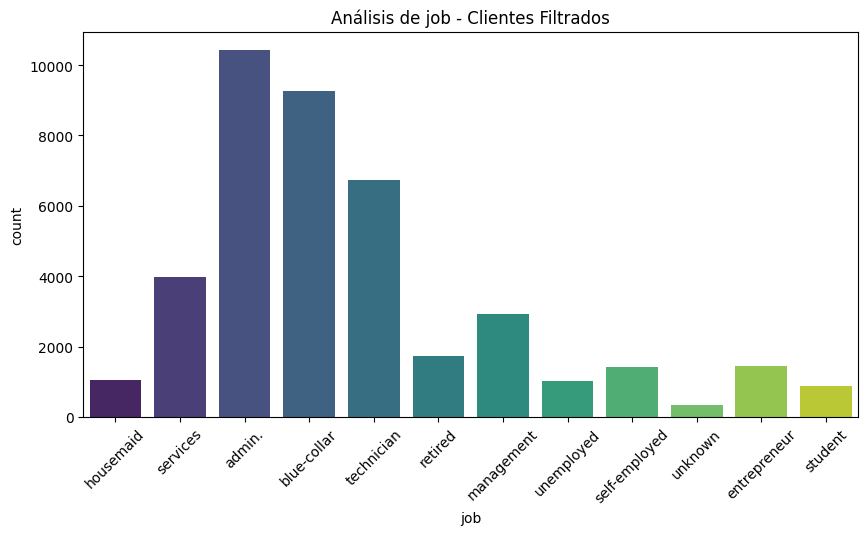

interactive(children=(Dropdown(description='Categoría:', options=('job', 'education', 'month'), value='job'), …

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ipywidgets import interact, widgets

# Cargar el dataset (ajusta la ruta si es necesario)
df = pd.read_csv('../data/raw/03-bank_marketing.csv', sep=';')

@interact(
    columna=widgets.Dropdown(options=['job', 'education', 'month'], description='Categoría:'),
    rango_edad=widgets.IntRangeSlider(value=[18, 95], min=18, max=95, step=1, description='Edad:'),
    solo_vivienda=widgets.Checkbox(value=False, description='Solo con Vivienda'),
    tipo_grafico=widgets.RadioButtons(options=['Barras', 'Conteo'], description='Estilo:')
)
def explorar_banco(columna, rango_edad, solo_vivienda, tipo_grafico):
    # 1. Filtrado de datos
    datos_filtrados = df[(df['age'] >= rango_edad[0]) & (df['age'] <= rango_edad[1])]
    
    if solo_vivienda:
        datos_filtrados = datos_filtrados[datos_filtrados['housing'] == 'yes']
    
    # 2. Visualización
    plt.figure(figsize=(10, 5))
    if tipo_grafico == 'Barras':
        sns.countplot(data=datos_filtrados, x=columna, palette='viridis')
    else:
        sns.histplot(data=datos_filtrados, x='age', kde=True)
        
    plt.xticks(rotation=45)
    plt.title(f"Análisis de {columna} - Clientes Filtrados")
    plt.show()

¿Por qué las variables Job, Education y Month?

1. Job (Ocupación)
Es la variable más importante para entender el perfil económico. El banco necesita saber si le está hablando a un emprendedor, a un jubilado o a un obrero, ya que sus necesidades de ahorro o crédito son totalmente distintas.

2. Education (Educación)
Esta categoría suele estar muy amarrada a la toma de decisiones. Como viste en tu gráfico, los universitarios son un grupo grande, y el banco utiliza este dato para saber qué tan complejos o técnicos pueden ser los mensajes publicitarios que les envían.

3. Month (Mes)
Esta es clave para la estacionalidad. Las campañas de marketing no funcionan igual en diciembre (época de gastos) que en agosto. Incluir el mes en tu Dropdown permite que el usuario vea si hubo meses donde se contactó a más gente o si el éxito de las llamadas cambió según la época del año.

¿Por qué un gráfico de barras y un histograma con KDE (conteo)?

- Opción "Barras" (Análisis Categórico): Sirve para comparar categorías. Por ejemplo, para ver si hay más universitarios que técnicos. Es ideal para entender el "perfil" del cliente.

- Opción "Conteo" (Distribución Numérica): En realidad es un Histograma. Sirve para ver cómo se distribuye una variable numérica (en este caso, la Edad). Es ideal para encontrar picos o concentraciones. Ejm: ver que la gran mayoría de clientes están entre los 30 y 40 años.

¿Por qué usar checkbox en "solo con vivienda (housing)"?

Si el cliente tiene vivienda (housing: yes): Es una persona que ya tiene una deuda importante cada mes. Podría ser más difícil que le sobre dinero para ahorrar en un depósito a plazo.

Si NO tiene vivienda (housing: no): Es probable que tenga más dinero para invertir en lo que el banco está ofreciendo ahora.

Si se activa, el dataset se reduce únicamente a los clientes con préstamos hipotecarios activos (housing == 'yes'). Si se deja desactivado, vemos toda la base de datos sin restricciones.